In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('adult.csv')

In [3]:
df.sample(5)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
5613,22,State-gov,178818,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,20,United-States,<=50K
8422,36,Federal-gov,67317,HS-grad,9,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States,<=50K
26071,41,Private,175674,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,40,United-States,>50K
14198,49,Private,278322,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,>50K
7561,20,Private,189888,12th,8,Never-married,Other-service,Not-in-family,White,Male,0,0,40,United-States,<=50K


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [5]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [7]:
df.nunique()

age                  73
workclass             9
fnlwgt            21648
education            16
education.num        16
marital.status        7
occupation           15
relationship          6
race                  5
sex                   2
capital.gain        119
capital.loss         92
hours.per.week       94
native.country       42
income                2
dtype: int64

In [8]:
(df == '?').sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [9]:
df = df.replace('?', np.nan)


for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()
df = df.replace('?', np.nan)  
df.isnull().sum()

C:\Users\snrip\AppData\Local\Temp\ipykernel_14180\1640387574.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [10]:
for col in ['workclass', 'occupation', 'native.country']:
    df[col] = df[col].fillna(df[col].mode()[0])

print('Total missing values remaining:', df.isnull().sum().sum())

Total missing values remaining: 0


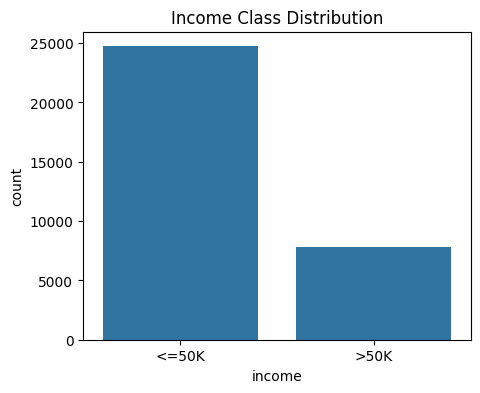

In [11]:
plt.figure(figsize=(5,4))
sns.countplot(x='income', data=df)
plt.title('Income Class Distribution')
plt.show()

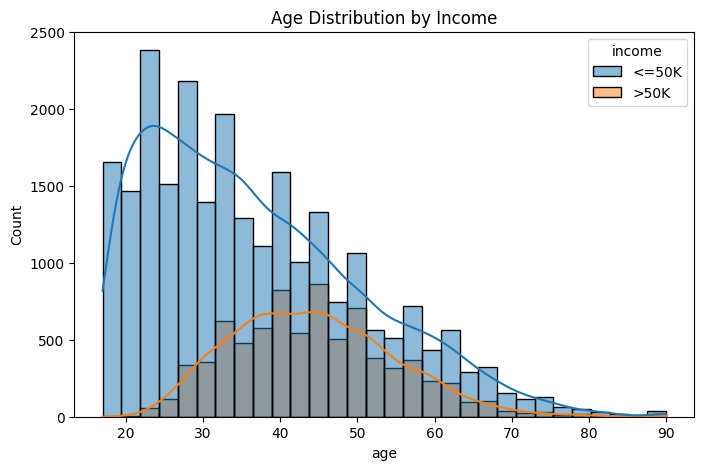

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', hue='income', kde=True, bins=30)
plt.title('Age Distribution by Income')
plt.show()

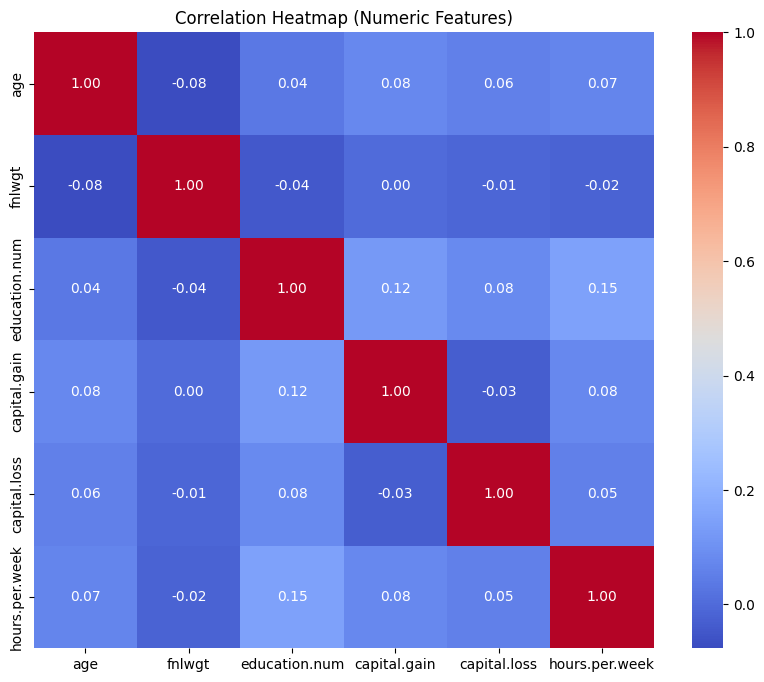

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

In [14]:
from sklearn.preprocessing import LabelEncoder

le_dict = {}
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le 
df.head()

C:\Users\snrip\AppData\Local\Temp\ipykernel_14180\334179027.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,3,77053,11,9,6,9,1,4,0,0,4356,40,38,0
1,82,3,132870,11,9,6,3,1,4,0,0,4356,18,38,0
2,66,3,186061,15,10,6,9,4,2,0,0,4356,40,38,0
3,54,3,140359,5,4,0,6,4,4,0,0,3900,40,38,0
4,41,3,264663,15,10,5,9,3,4,0,0,3900,40,38,0


In [15]:
X = df.drop('income', axis=1)
y = df['income']

print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('\nTarget class balance:\n', y.value_counts(normalize=True))

Features shape: (32561, 14)
Target shape: (32561,)

Target class balance:
 income
0    0.75919
1    0.24081
Name: proportion, dtype: float64


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 

In [19]:
models={
    "Logisitic Regression":LogisticRegression(),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(),
    "Gradient Boost":GradientBoostingClassifier(),
    "XGB Classifier": XGBClassifier(tree_method="hist", device="cuda")
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc


    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    
    print('='*35)
    print('\n')

d:\ml_projects_git_hub\mlenv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logisitic Regression
Model performance for Training set
- Accuracy: 0.7935
- F1 score: 0.7643
- Precision: 0.6513
- Recall: 0.3064
- Roc Auc Score: 0.6272
----------------------------------
Model performance for Test set
- Accuracy: 0.7898
- F1 score: 0.7578
- Precision: 0.6432
- Recall: 0.2851
- Roc Auc Score: 0.6175


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.8070
- F1 score: 0.8069
- Precision: 0.5995
- Recall: 0.5976
- Roc Auc Score: 0.7355


Random Forest
Model performance for Training set
- Accuracy: 0.9999
- F1 score: 0.9999
- Precision: 1.0000
- Recall: 0.9997
- Roc Auc Score: 0.9998
----------------------------------
Model performance for Test set
- Accuracy: 0.8544
- F1 score: 0.8501
- Precision: 0.7341
- Recall: 0.6199
- Roc Auc Score: 0.7744


Gradient Boost
Model performance for Training se

d:\ml_projects_git_hub\mlenv\Lib\site-packages\xgboost\core.py:751: UserWarning: [13:55:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [20]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

xgb_base = XGBClassifier(tree_method='hist', device='cuda', random_state=42, eval_metric='logloss')

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=25,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print('Best hyperparameters:', random_search.best_params_)
print('Best CV F1 score: {:.4f}'.format(random_search.best_score_))

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best hyperparameters: {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
Best CV F1 score: 0.7125


In [21]:
best_xgb = random_search.best_estimator_

y_train_pred = best_xgb.predict(X_train)
y_test_pred = best_xgb.predict(X_test)

print('Tuned XGB Classifier')
print('Model performance for Training set')
print('- Accuracy: {:.4f}'.format(accuracy_score(y_train, y_train_pred)))
print('- F1 score: {:.4f}'.format(f1_score(y_train, y_train_pred, average='weighted')))
print('- Precision: {:.4f}'.format(precision_score(y_train, y_train_pred)))
print('- Recall: {:.4f}'.format(recall_score(y_train, y_train_pred)))
print('- Roc Auc Score: {:.4f}'.format(roc_auc_score(y_train, y_train_pred)))

print('----------------------------------')

print('Model performance for Test set')
print('- Accuracy: {:.4f}'.format(accuracy_score(y_test, y_test_pred)))
print('- F1 score: {:.4f}'.format(f1_score(y_test, y_test_pred, average='weighted')))
print('- Precision: {:.4f}'.format(precision_score(y_test, y_test_pred)))
print('- Recall: {:.4f}'.format(recall_score(y_test, y_test_pred)))
print('- Roc Auc Score: {:.4f}'.format(roc_auc_score(y_test, y_test_pred)))

Tuned XGB Classifier
Model performance for Training set
- Accuracy: 0.8865
- F1 score: 0.8830
- Precision: 0.8134
- Recall: 0.6860
- Roc Auc Score: 0.8180
----------------------------------
Model performance for Test set
- Accuracy: 0.8690
- F1 score: 0.8648
- Precision: 0.7727
- Recall: 0.6460
- Roc Auc Score: 0.7929


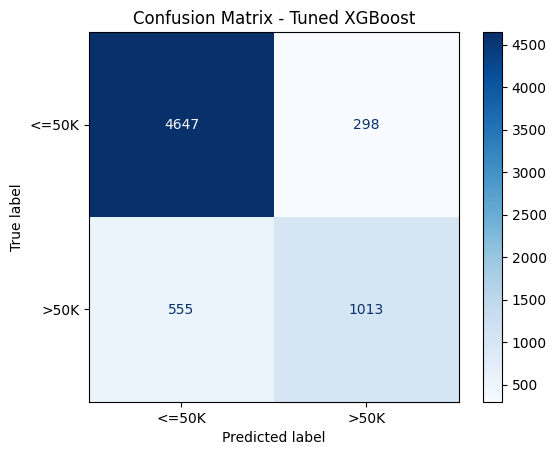

In [22]:
from sklearn.metrics import confusion_matrix
cm_tuned = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm_tuned, display_labels=['<=50K', '>50K']).plot(cmap='Blues')
plt.title('Confusion Matrix - Tuned XGBoost')
plt.show()

In [23]:
# Example: a 37-year-old private-sector worker, Bachelor's degree, married, works 45 hrs/week
sample = {
    'age': 37,
    'workclass': 'Private',
    'fnlwgt': 200000,
    'education': 'Bachelors',
    'education.num': 13,
    'marital.status': 'Married-civ-spouse',
    'occupation': 'Exec-managerial',
    'relationship': 'Husband',
    'race': 'White',
    'sex': 'Male',
    'capital.gain': 0,
    'capital.loss': 0,
    'hours.per.week': 45,
    'native.country': 'United-States'
}

sample_df = pd.DataFrame([sample])

# Encode categorical fields using the SAME encoders fit during training
for col in cat_cols:
    if col in sample_df.columns:
        sample_df[col] = le_dict[col].transform(sample_df[col])

# Make sure column order matches X_train exactly
sample_df = sample_df[X_train.columns]

prediction = best_xgb.predict(sample_df)[0]
prediction_proba = best_xgb.predict_proba(sample_df)[0]

predicted_label = le_dict['income'].inverse_transform([prediction])[0] if 'income' in le_dict else ('>50K' if prediction == 1 else '<=50K')

print('Predicted income class:', predicted_label)
print('Probability [<=50K, >50K]:', prediction_proba)

Predicted income class: >50K
Probability [<=50K, >50K]: [0.20250177 0.7974982 ]


In [26]:
import joblib
joblib.dump(best_xgb, 'xgb_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# later
model = joblib.load('xgb_model.pkl')
scaler = joblib.load('scaler.pkl')